# Fatigue Classifier — XGBoost
Plug in awake + drowsy CSVs, run all cells.


In [ ]:

!pip install -q xgboost scikit-learn matplotlib seaborn pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import warnings; warnings.filterwarnings('ignore')
print('✓ Imports done')


✓ Imports done


In [ ]:

AWAKE_CSV  = '/media/rudhratej/linux_data/projects/personal/multimodal_driver_fatigue_monitor/src/data/awake_features.csv'
DROWSY_CSV = '/media/rudhratej/linux_data/projects/personal/multimodal_driver_fatigue_monitor/src/data/drowsy_features.csv'

awake  = pd.read_csv(AWAKE_CSV);  awake['label']  = 0
drowsy = pd.read_csv(DROWSY_CSV); drowsy['label'] = 1

df = pd.concat([awake, drowsy], ignore_index=True)
print(f'Awake rows : {len(awake)}')
print(f'Drowsy rows: {len(drowsy)}')
print(f'Total      : {len(df)}')
df.head()


Awake rows : 96
Drowsy rows: 90
Total      : 186


,timestamp,EAR_min,EAR_var,MAR_mean,MAR_var,blink_count_10s,avg_blink_duration_10s,pitch,roll,cnn_eye_state,cnn_p_sleepy,label
0,10.000,0.8392,0.0020,0.9995,0.0000,0,0.0000,14.693,-0.498,awake,0.4824,0
1,20.002,0.7390,0.0076,1.0039,0.0001,1,0.0167,22.438,-7.352,awake,0.4853,0
2,30.002,0.7779,0.0042,1.0043,0.0000,0,0.0000,18.424,-0.954,awake,0.4837,0
3,40.002,0.8240,0.0030,1.0038,0.0001,0,0.0000,21.327,-2.191,awake,0.4840,0
4,50.003,0.8656,0.0030,1.0024,0.0000,0,0.0000,28.949,-3.135,awake,0.4835,0


In [ ]:

DROP_COLS = ['timestamp', 'cnn_eye_state']
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)


df.replace('no_model', np.nan, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.fillna(df.median(numeric_only=True), inplace=True)

FEATURES = [c for c in df.columns if c != 'label']
X = df[FEATURES].values
y = df['label'].values

print('Features:', FEATURES)
print('Class balance — awake:', (y==0).sum(), '| drowsy:', (y==1).sum())


Features: ['EAR_min', 'EAR_var', 'MAR_mean', 'MAR_var', 'blink_count_10s', 'avg_blink_duration_10s', 'pitch', 'roll', 'cnn_p_sleepy']
Class balance — awake: 96 | drowsy: 90


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)}  Test: {len(X_test)}')


Train: 148  Test: 38


In [8]:
model = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 1,
    gamma             = 0.1,
    reg_alpha         = 0.1,    
    reg_lambda        = 1.0,    
    scale_pos_weight  = (y==0).sum() / (y==1).sum(), 
    eval_metric       = 'logloss',
    early_stopping_rounds = 30,
    random_state      = 42,
    verbosity         = 0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f'best iter {model.best_iteration}')
print(f'train acc: {(model.predict(X_train)==y_train).mean():.4f}')
print(f'test  acc: {(model.predict(X_test) ==y_test ).mean():.4f}')


best iter 102
train acc: 0.9730
test  acc: 0.8947


In [ ]:


cv_model = XGBClassifier(
    n_estimators=model.best_iteration or 100,
    max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=42, verbosity=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(cv_model, X, y, cv=cv, scoring='roc_auc')
print(f'5-fold ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')
print(f'Per fold: {scores.round(4)}')


5-fold ROC-AUC: 0.8991 ± 0.0682
Per fold: [0.9167 0.9152 0.924  0.9708 0.769 ]


              precision    recall  f1-score   support

       awake       0.90      0.90      0.90        20
      drowsy       0.89      0.89      0.89        18

    accuracy                           0.89        38
   macro avg       0.89      0.89      0.89        38
weighted avg       0.89      0.89      0.89        38

ROC-AUC: 0.9333


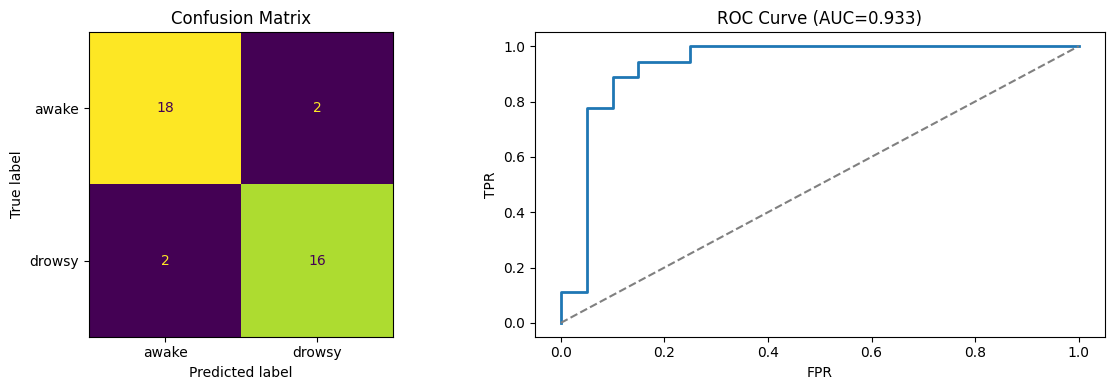

In [ ]:


y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['awake','drowsy']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['awake','drowsy']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2)
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f'ROC Curve (AUC={roc_auc_score(y_test,y_proba):.3f})')

plt.tight_layout(); plt.show()


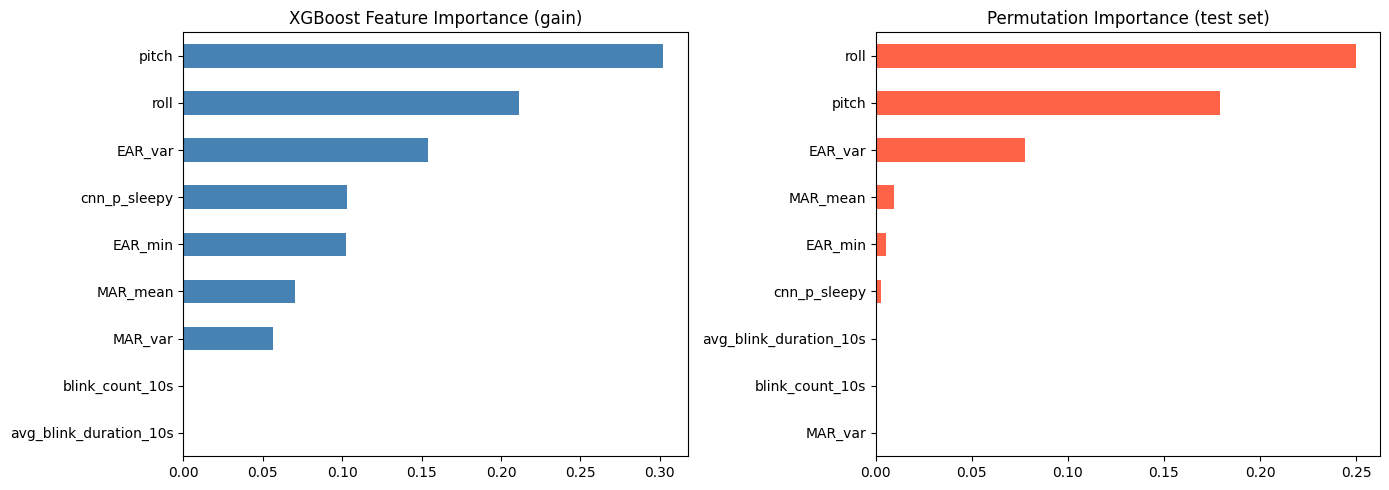

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('XGBoost Feature Importance (gain)')


perm = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=42)
perm_s = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=True)
perm_s.plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Permutation Importance (test set)')

plt.tight_layout(); plt.show()


In [ ]:

import joblib

joblib.dump(model, 'fatigue_xgb.pkl')
print('✓ Model saved to fatigue_xgb.pkl')

import json
with open('feature_names.json', 'w') as f:
    json.dump(FEATURES, f)
print('✓ Feature names saved to feature_names.json')


✓ Model saved to fatigue_xgb.pkl
✓ Feature names saved to feature_names.json
